# Concept Allocation Zone (CAZ) Framework Introduction

*Mechanistic interpretability without picking a layer*

How do transformer models encode concepts like *causation*, *negation*, or *sentiment*? The standard approach picks a "good layer" and probes it. The **Concept Allocation Zone (CAZ)** framework asks a different question: across which layers does the model *construct* each concept — and is the answer consistent across architectures?

This notebook tours the main findings from Papers 1–3 using pre-computed results for four models downloaded from Hugging Face. No model loading or GPU required.

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a–c)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("huggingface_hub", "matplotlib", "numpy", "scipy", "scikit-learn")

ERROR: Could not find a version that satisfies the requirement rosetta_tools>=1.3.1 (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for rosetta_tools>=1.3.1

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

HF_REPO = "james-ra-henry/Rosetta-Activations"

# Four models spanning different architectures and scales
MODELS = {
    "Qwen2.5-7B":   "Qwen/Qwen2.5-7B",         # 28L, GQA
    "Pythia-6.9B":  "EleutherAI/pythia-6.9b",   # 32L, MHA
    "Pythia-70M":   "EleutherAI/pythia-70m",     # 6L, MHA, tiny
    "Gemma-2-2B":   "google/gemma-2-2b",         # 26L, alternating attention
}

# Four concepts with strong multimodal properties for the cross-architecture demo
CONCEPTS = ["agency", "certainty", "negation", "temporal_order"]

# All 8 Pythia scale checkpoints — same architecture, same data, 70M → 12B
PYTHIA_MODELS = {
    "Pythia-70M":   "EleutherAI/pythia-70m",
    "Pythia-160M":  "EleutherAI/pythia-160m",
    "Pythia-410M":  "EleutherAI/pythia-410m",
    "Pythia-1B":    "EleutherAI/pythia-1b",
    "Pythia-1.4B":  "EleutherAI/pythia-1.4b",
    "Pythia-2.8B":  "EleutherAI/pythia-2.8b",
    "Pythia-6.9B":  "EleutherAI/pythia-6.9b",
    "Pythia-12B":   "EleutherAI/pythia-12b",
}

# Concepts available for all models in the Rosetta Activations dataset
ALL_CONCEPTS = [
    "temporal_order", "causation", "agency",
    "negation", "sentiment", "moral_valence",
    "urgency", "certainty", "credibility",
    "sarcasm", "specificity",
]

def model_key(model_id: str) -> str:
    """Convert HuggingFace model ID to the directory key used in the dataset."""
    return model_id.replace("/", "_").replace("-", "_")

print("Setup complete.")

In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


In [4]:
# ── Available models — swap any into MODELS above ────────────────────────────
# All have pre-computed CAZ results in the Rosetta Activations dataset.
# Replace any entry in MODELS with one of these model IDs.
#
# SMALL (< 1B)
#   "openai-community/gpt2"           # 12L,   768-dim
#   "openai-community/gpt2-large"     # 36L,  1280-dim
#   "openai-community/gpt2-xl"        # 48L,  1600-dim
#   "EleutherAI/pythia-70m"           # 6L,    512-dim
#   "EleutherAI/pythia-160m"          # 12L,   768-dim
#   "EleutherAI/pythia-410m"          # 24L,  1024-dim
#   "Qwen/Qwen2.5-0.5B"              # 24L,   896-dim
#   "facebook/opt-125m"               # 12L,   768-dim
#   "facebook/opt-350m"               # 24L,  1024-dim
#
# MEDIUM (1–4B)
#   "EleutherAI/pythia-1b"            # 16L,  2048-dim
#   "EleutherAI/pythia-1.4b"          # 24L,  2048-dim
#   "EleutherAI/pythia-2.8b"          # 32L,  2560-dim
#   "Qwen/Qwen2.5-1.5B"              # 28L,  1536-dim
#   "Qwen/Qwen2.5-3B"                # 36L,  2048-dim
#   "meta-llama/Llama-3.2-1B"        # 16L,  2048-dim
#   "meta-llama/Llama-3.2-3B"        # 28L,  3072-dim
#   "microsoft/phi-2"                 # 32L,  2560-dim
#   "facebook/opt-1.3b"              # 24L,  2048-dim
#   "facebook/opt-2.7b"              # 32L,  2560-dim
#
# LARGE (6–14B)
#   "Qwen/Qwen2.5-7B"                # 28L,  3584-dim  ← default
#   "Qwen/Qwen2.5-14B"               # 48L,  5120-dim
#   "EleutherAI/pythia-6.9b"         # 32L,  4096-dim  ← default
#   "EleutherAI/pythia-12b"          # 36L,  5120-dim
#   "google/gemma-2-2b"              # 26L,  2304-dim  ← default
#   "google/gemma-2-9b"              # 42L,  3584-dim
#   "google/gemma-4-26B-A4B"         # 30L,  2816-dim  (MoE)
#   "meta-llama/Llama-3.1-8B"        # 32L,  4096-dim
#   "mistralai/Mistral-7B-v0.3"      # 32L,  4096-dim
#   "facebook/opt-6.7b"              # 32L,  4096-dim
#
# VERY LARGE (32B+)
#   "Qwen/Qwen2.5-32B"               # 64L,  5120-dim
#   "Qwen/Qwen2.5-72B"               # 80L,  8192-dim
#   "tiiuae/falcon-40b"              # 60L,  8192-dim
#   "meta-llama/Llama-3.1-70B"       # 80L,  8192-dim

## 1. Download pre-computed CAZ results

Pre-computed CAZ results for 34 models are stored in the [Rosetta Activations](https://huggingface.co/datasets/james-ra-henry/Rosetta-Activations) dataset on Hugging Face. Each file contains, for every layer: Fisher separation $S(l)$, coherence $C(l)$, velocity $v(l)$, and the dominant concept direction.

This cell downloads results for four representative models across four concepts.

In [5]:
caz = {}
for label, model_id in MODELS.items():
    caz[label] = {}
    for concept in CONCEPTS:
        filename = f"models/{model_key(model_id)}/caz_{concept}.json"
        path = hf_hub_download(HF_REPO, filename=filename, repo_type="dataset")
        with open(path) as f:
            caz[label][concept] = json.load(f)

print(f"{'Model':25s}  {'Layers':>6s}  {'Hidden dim':>10s}")
print("-" * 45)
for label in MODELS:
    d = caz[label][CONCEPTS[0]]
    print(f"{label:25s}  {d['n_layers']:6d}  {d['hidden_dim']:10d}")

Model                      Layers  Hidden dim
---------------------------------------------
Qwen2.5-7B                     28        3584
Pythia-6.9B                    32        4096
Pythia-70M                      6         512
Gemma-2-2B                     26        2304


## 2. The three signals

CAZ measures concept construction through three layer-wise signals:

| Signal | Symbol | What it captures |
|--------|--------|------------------|
| **Separation** | $S(l)$ | Fisher-normalized centroid distance between positive and negative class activations |
| **Coherence** | $C(l)$ | Mean cosine similarity to class centroid — how organized each class is internally |
| **Velocity** | $v(l)$ | Rate of change of separation — peaks at the onset of rapid concept construction |

A **Concept Allocation Zone** is a layer region where $S(l)$ peaks with supporting $C(l)$. The velocity peak precedes the separation peak, marking the start of construction.

In [ ]:
concept = "agency"
model_label = "Qwen2.5-7B"

d = caz[model_label][concept]
metrics = d["layer_data"]["metrics"]
n_layers = d["n_layers"]
depth = [m["layer"] / n_layers * 100 for m in metrics]

# Signal colors: fixed semantics, not concept-specific
SIG_COLORS = {"separation": "#1565C0", "coherence": "#2E7D32", "velocity": "#E65100"}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle(f"{model_label} — '{concept}'", fontsize=13, fontweight="bold")

for ax, key, ylabel, color in zip(
    axes,
    ["separation_fisher", "coherence", "velocity"],
    ["Separation  S(l)", "Coherence  C(l)", "Velocity  v(l)"],
    [SIG_COLORS["separation"], SIG_COLORS["coherence"], SIG_COLORS["velocity"]],
):
    vals = [m[key] for m in metrics]
    ax.plot(depth, vals, color=color, lw=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color=THEME["spine"], lw=0.8, ls="--")
    apply_theme(ax)

peak_pct = d["layer_data"]["peak_depth_pct"]
for ax in axes:
    ax.axvline(peak_pct, color="#C62828", lw=1.5, ls=":", alpha=0.7)

axes[-1].set_xlabel("Depth (% of layers)", fontsize=11)
axes[0].annotate(f"peak {peak_pct:.0f}%", xy=(peak_pct, axes[0].get_ylim()[1]),
                 xytext=(peak_pct + 3, axes[0].get_ylim()[1] * 0.85),
                 color="#C62828", fontsize=9)
plt.tight_layout()
plt.show()

### CAZ anatomy: allocation zones as shaded regions

A single S(l) trace hides the internal structure. `find_caz_regions` detects each distinct peak and its bounding region (where separation rises and falls around that peak). The shaded bands below show the **extent** of each Concept Allocation Zone — not just the peak depth, but the full layer range over which the concept is being assembled.

★ marks multimodal cases where two separate allocation events occur.

In [ ]:
from rosetta_tools.caz import LayerMetrics, find_caz_regions

ZONE_COLORS = ["#1565C0", "#E65100", "#2E7D32", "#7B1FA2"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=False)
fig.patch.set_facecolor("white")
fig.suptitle(f"CAZ anatomy — 'agency' across four architectures", fontsize=13, fontweight="bold")

for ax, (label, model_id) in zip(axes.flat, MODELS.items()):
    d = caz[label]["agency"]
    metrics = d["layer_data"]["metrics"]
    n_layers = d["n_layers"]
    depth_x = [m["layer"] / n_layers * 100 for m in metrics]
    sep     = [m["separation_fisher"] for m in metrics]

    layer_metrics = [
        LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                     coherence=m["coherence"], velocity=m["velocity"])
        for m in metrics
    ]
    profile = find_caz_regions(layer_metrics)

    color = concept_color("agency")
    ax.plot(depth_x, sep, color=color, lw=2.2, zorder=3)
    ax.fill_between(depth_x, sep, alpha=0.10, color=color, zorder=2)

    for i, region in enumerate(profile.regions):
        start_pct = region.start / n_layers * 100
        end_pct   = region.end   / n_layers * 100
        zc = ZONE_COLORS[i % len(ZONE_COLORS)]
        ax.axvspan(start_pct, end_pct, alpha=0.18, color=zc, zorder=1,
                   label=f"CAZ {i+1}  ({region.depth_pct:.0f}%)")
        ax.axvline(region.depth_pct, color=zc, lw=1.3, ls="--", alpha=0.75, zorder=4)

    mm_tag = "  ★ multimodal" if profile.is_multimodal else ""
    n = profile.n_regions
    ax.set_title(f"{label}  —  {n} zone{'s' if n != 1 else ''}{mm_tag}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Depth (% of layers)", fontsize=9)
    ax.set_ylabel("S(l) — Separation", fontsize=9)
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8, loc="upper left")
    apply_theme(ax)

plt.tight_layout()
plt.show()

## 3. The concept ordering

One of the most consistent findings across all 34 tested models: concepts assemble in the **same relative order** — shallow to deep — regardless of architecture, scale, or training objective.

Surface/structural features (negation, plurality) tend to peak earlier in the model; relational/evaluative features (causation, temporal order) tend to peak deeper. The following cell extracts the dominant peak depth for each concept across all four models.

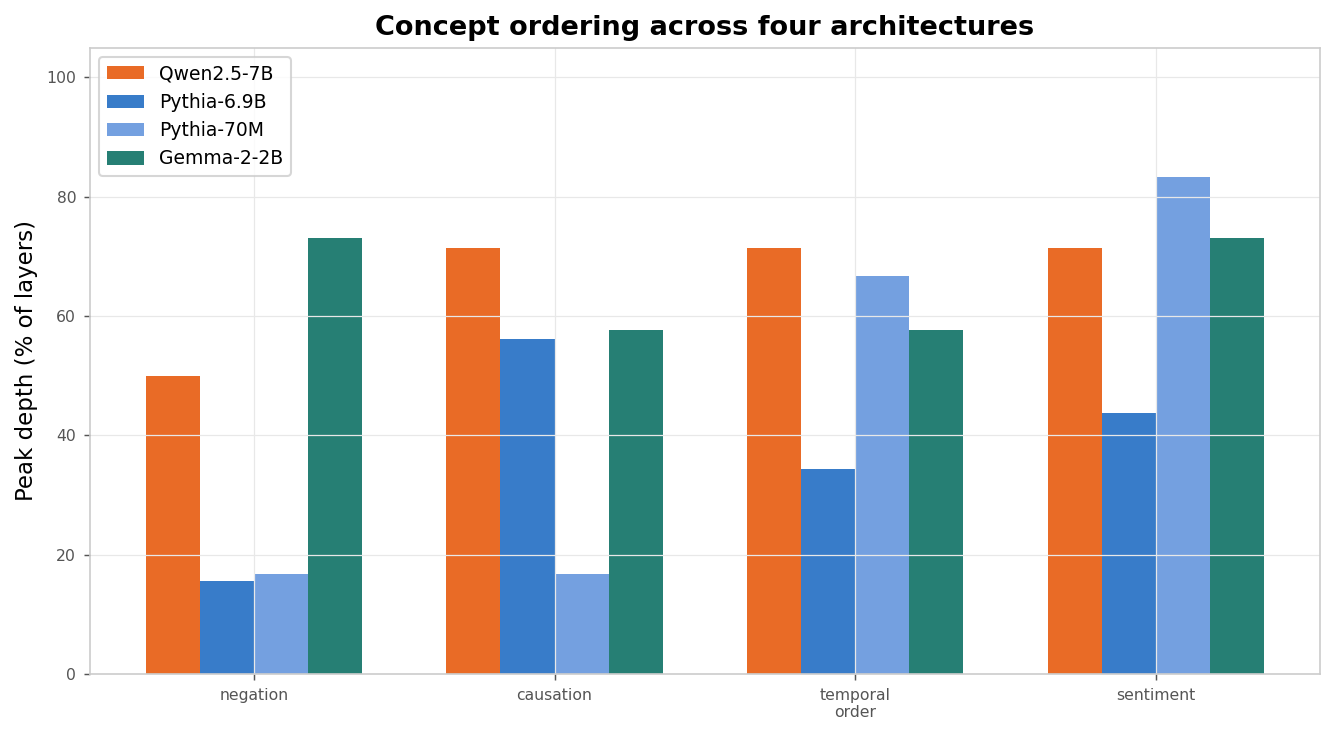

Mean peak depth (shallow → deep):
  negation              38.8%
  causation             50.5%
  temporal_order        57.5%
  sentiment             67.9%


In [7]:
# Collect peak depths
peak_depths = {label: {} for label in MODELS}
for label in MODELS:
    for concept in CONCEPTS:
        peak_depths[label][concept] = caz[label][concept]["layer_data"]["peak_depth_pct"]

mean_depth = {c: np.mean([peak_depths[l][c] for l in MODELS]) for c in CONCEPTS}
ordered = sorted(CONCEPTS, key=mean_depth.get)

# Use family colors — each model gets its architecture's canonical color
model_colors = {
    "Qwen2.5-7B":  FAMILY_COLORS["Qwen"],
    "Pythia-6.9B": FAMILY_COLORS["Pythia"],
    "Pythia-70M":  "#5C8FDB",   # lighter Pythia blue for the smaller model
    "Gemma-2-2B":  FAMILY_COLORS["Gemma"],
}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
width = 0.18
xpos = np.arange(len(ordered))

for i, (label, color) in enumerate(model_colors.items()):
    depths = [peak_depths[label][c] for c in ordered]
    ax.bar(xpos + i * width, depths, width, label=label, color=color, alpha=0.85)

ax.set_xticks(xpos + width * 1.5)
ax.set_xticklabels([c.replace("_", "\n") for c in ordered], fontsize=11)
ax.set_ylabel("Peak depth (% of layers)", fontsize=11)
ax.set_title("Concept ordering across four architectures", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc="upper left")
apply_theme(ax)
plt.tight_layout()
plt.show()

print("Mean peak depth (shallow → deep):")
for c in ordered:
    print(f"  {c:20s}  {mean_depth[c]:.1f}%")

## 4. Scale effects

Does model size shift where concepts are assembled? The Pythia family (70M → 12B parameters) lets us isolate scale from architecture: same training data, same attention paradigm, only depth and width change.

Paper 3 finds that relational concepts (causation, temporal order) tend to shift to **earlier proportional depths** in larger models — they converge sooner relative to total depth. Epistemic and surface concepts are more scale-invariant.

The cell below downloads CAZ results for all 8 Pythia checkpoints × all 11 available concepts, then plots peak depth for every concept across the full scale range.

In [ ]:
# Download CAZ results for all 8 Pythia checkpoints × 11 concepts
# (~30 s first run; cached locally thereafter)
pythia_caz = {}
for label, model_id in PYTHIA_MODELS.items():
    pythia_caz[label] = {}
    for concept in ALL_CONCEPTS:
        filename = f"models/{model_key(model_id)}/caz_{concept}.json"
        path = hf_hub_download(HF_REPO, filename=filename, repo_type="dataset")
        with open(path) as f:
            pythia_caz[label][concept] = json.load(f)

print(f"Downloaded: {len(PYTHIA_MODELS)} models × {len(ALL_CONCEPTS)} concepts = {len(PYTHIA_MODELS)*len(ALL_CONCEPTS)} files")

In [ ]:
pythia_labels = list(PYTHIA_MODELS.keys())
x = np.arange(len(pythia_labels))

# Collect peak depths
pythia_peak = {label: {} for label in PYTHIA_MODELS}
for label in PYTHIA_MODELS:
    for concept in ALL_CONCEPTS:
        pythia_peak[label][concept] = pythia_caz[label][concept]["layer_data"]["peak_depth_pct"]

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("white")

for concept in ALL_CONCEPTS:
    depths = [pythia_peak[label][concept] for label in pythia_labels]
    ax.plot(x, depths, "o-", color=concept_color(concept), lw=1.8, ms=5,
            label=concept.replace("_", " "), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pythia_labels, fontsize=10, rotation=20, ha="right")
ax.set_ylabel("Peak depth (% of layers)", fontsize=11)
ax.set_title("Scale effects — Pythia 70M → 12B, all 11 concepts", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.legend(fontsize=8, ncol=2, loc="upper right", framealpha=0.9)
apply_theme(ax)
plt.tight_layout()
plt.show()

## 5. Multimodal allocation: more than one peak

The separation curve for many concepts has **two distinct peaks** — a shallow one (lexical/structural processing) and a deep one (compositional/semantic integration). This is the CAZ "dark matter": a single-layer probe misses one of the two events.

Paper 3 finds multimodal allocation in the majority of models tested across most concepts. The cell below uses `find_caz_regions` from `rosetta_tools` to count peaks per concept per model.

In [9]:
from rosetta_tools.caz import LayerMetrics, find_caz_regions

rows = []
for label in MODELS:
    for concept in CONCEPTS:
        raw = caz[label][concept]["layer_data"]["metrics"]
        layer_metrics = [
            LayerMetrics(
                layer=m["layer"],
                separation=m["separation_fisher"],
                coherence=m["coherence"],
                velocity=m["velocity"],
            )
            for m in raw
        ]
        profile = find_caz_regions(layer_metrics)
        rows.append({
            "model": label,
            "concept": concept,
            "n_regions": profile.n_regions,
            "multimodal": profile.is_multimodal,
            "peak_depths": ", ".join(f"{r.depth_pct:.0f}%" for r in profile.regions),
        })

print(f"  {'Model':25s}  {'Concept':20s}  {'Peaks':>5s}  Depth(s)")
print("  " + "-" * 72)
for r in rows:
    flag = "★" if r["multimodal"] else " "
    print(f"{flag} {r['model']:25s}  {r['concept']:20s}  {r['n_regions']:5d}  {r['peak_depths']}")

mm = sum(1 for r in rows if r["multimodal"])
print(f"\nMultimodal: {mm}/{len(rows)} ({100*mm/len(rows):.0f}%)  (★ = two or more allocation events)")

  Model                      Concept               Peaks  Depth(s)
  ------------------------------------------------------------------------
  Qwen2.5-7B                 causation                 1  71%
  Qwen2.5-7B                 sentiment                 1  71%
  Qwen2.5-7B                 negation                  1  50%
  Qwen2.5-7B                 temporal_order            1  71%
  Pythia-6.9B                causation                 1  56%
  Pythia-6.9B                sentiment                 1  44%
★ Pythia-6.9B                negation                  2  6%, 16%
  Pythia-6.9B                temporal_order            1  34%
  Pythia-70M                 causation                 1  17%
  Pythia-70M                 sentiment                 1  83%
  Pythia-70M                 negation                  1  17%
★ Pythia-70M                 temporal_order            2  17%, 67%
  Gemma-2-2B                 causation                 1  58%
  Gemma-2-2B                 sentiment     

## Summary

The CAZ framework reveals three consistent properties of concept encoding in transformers:

1. **Process, not snapshot** — concepts build across many layers; there is no single "concept layer"
2. **Universal ordering** — the relative assembly order (shallow → deep) is consistent across architectures and scales
3. **Multimodal allocation** — many concepts have two distinct assembly events; single-layer probes miss one of them

---

### Next notebooks

| Notebook | What it does |
|----------|--------------|
| `02_caz_interactive_demo.ipynb` | Load Qwen2.5-7B (4-bit) and run CAZ on your own concept pairs |
| `03_caz_implementation_demo.ipynb` | Implement the metrics and Procrustes alignment from scratch; reproduce the cross-architecture convergence result from Paper 4 |

### Papers and resources

| Resource | |
|----------|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 2 — GEM | [Henry 2026b](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 3 — CAZ Validation | [Henry 2026c](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` library | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |
| Concept pairs dataset | [Rosetta_Concept_Pairs](https://github.com/jamesrahenry/Rosetta_Concept_Pairs) |